In [44]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [45]:
# Question 2.1
wifi = pd.read_csv("wifi_localization.csv")
original_rows = len(wifi)
wifi["Room"] = wifi["Room"].astype(str).str.strip()
wifi = wifi[
    wifi["Room"].str.lower() != "unknown"
].copy()

removed_rows = original_rows - len(wifi)
remaining_rows = len(wifi)

print("Removed:", removed_rows)
print("Remaining:", remaining_rows)

Removed: 50
Remaining: 1950


   WiFi_1  WiFi_2  WiFi_3  WiFi_4  WiFi_5  WiFi_6  WiFi_7  Room
0     -64     -56     -61     -66     -71     -82     -81     1
1     -68     -57     -61     -65     -71     -85     -85     1
2     -63     -60     -60     -67     -76     -85     -84     1
3     -61     -60     -68     -62     -77     -90     -80     1
4     -63     -65     -60     -63     -77     -81     -87     1

Column names:
['WiFi_1', 'WiFi_2', 'WiFi_3', 'WiFi_4', 'WiFi_5', 'WiFi_6', 'WiFi_7', 'Room']
Room distribution:
Room
1    487
2    485
3    489
4    489
Name: count, dtype: int64


<Axes: title={'center': 'Distribution of Samples Across Rooms'}, xlabel='Room', ylabel='Number of Samples'>

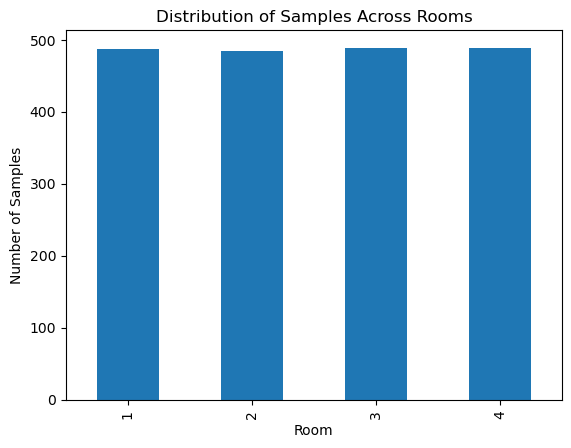

In [46]:
#Question 2.2 
# Convert Room from text to numeric values
wifi["Room"] = pd.to_numeric(wifi["Room"]).astype(int)
print(wifi.head())
print("\nColumn names:")
print(wifi.columns.tolist())
# Question 2.2(b)
room_distribution = wifi["Room"].value_counts().sort_index()
print("Room distribution:")
print(room_distribution)

room_distribution.plot(
    kind="bar",
    title="Distribution of Samples Across Rooms",
    xlabel="Room",
    ylabel="Number of Samples"
)

In [47]:
# Question 2.3
X = wifi.drop(columns=["Room"])
y = wifi["Room"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 1560
Test samples: 390


In [48]:
# Question 2.4
zid = 5576935
default_k = zid % 5 + 2
print("Default n_neighbors:", default_k)

# Create and train the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=default_k)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", knn_accuracy)

# Confusion matrix
knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=[1, 2, 3, 4]
)

confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=["Actual Room 1", "Actual Room 2",
           "Actual Room 3", "Actual Room 4"],
    columns=["Predicted Room 1", "Predicted Room 2",
             "Predicted Room 3", "Predicted Room 4"]
)

print("\nConfusion Matrix:")
print(confusion_table)

# Precision, recall and F1-score for each room
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

Default n_neighbors: 2

Accuracy: 0.982051282051282

Confusion Matrix:
               Predicted Room 1  Predicted Room 2  Predicted Room 3  \
Actual Room 1                97                 0                 0   
Actual Room 2                 0                95                 2   
Actual Room 3                 0                 3                95   
Actual Room 4                 2                 0                 0   

               Predicted Room 4  
Actual Room 1                 0  
Actual Room 2                 0  
Actual Room 3                 0  
Actual Room 4                96  

Classification Report:
              precision    recall  f1-score   support

           1     0.9798    1.0000    0.9898        97
           2     0.9694    0.9794    0.9744        97
           3     0.9794    0.9694    0.9744        98
           4     1.0000    0.9796    0.9897        98

    accuracy                         0.9821       390
   macro avg     0.9821    0.9821    0.9821       390

In [49]:
## Problem 3

In [50]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [51]:
# Load the credit-risk dataset
credit = pd.read_csv("credit_risk.csv")

print(credit.head())
print("\nDataset shape:", credit.shape)
print("\nColumn names:")
print(credit.columns.tolist())

  CheckingStatus         CreditHistory LoanPurpose ExistingSavings  \
0         less_0    outstanding_credit    radio_tv         unknown   
1    no_checking    outstanding_credit   education        less_100   
2         less_0  credits_paid_to_date   furniture        less_100   
3    no_checking  credits_paid_to_date   education         unknown   
4    no_checking  credits_paid_to_date   furniture     500_to_1000   

  EmploymentDuration OthersOnLoan       OwnsProperty InstallmentPlans Housing  \
0          greater_7         none        real_estate             none     own   
1             4_to_7         none        real_estate             none     own   
2             4_to_7    guarantor  savings_insurance             none    free   
3             1_to_4         none            unknown             none    free   
4          greater_7         none  savings_insurance             none     own   

         Job Telephone ForeignWorker     Risk  
0    skilled       yes           yes  No Ris

In [52]:
# Create a copy of the dataset
credit_encoded = credit.copy()
label_encoders = {}

# Encode every categorical column
for column in credit_encoded.columns:
    encoder = LabelEncoder()
    credit_encoded[column] = encoder.fit_transform(
        credit_encoded[column].astype(str)
    )
    label_encoders[column] = encoder

print(credit_encoded.head())

print("\nRisk category mapping:")
for number, category in enumerate(label_encoders["Risk"].classes_):
    print(number, "=", category)

   CheckingStatus  CreditHistory  LoanPurpose  ExistingSavings  \
0               2              3            7                4   
1               3              3            4                3   
2               2              1            5                3   
3               3              1            4                4   
4               3              1            5                1   

   EmploymentDuration  OthersOnLoan  OwnsProperty  InstallmentPlans  Housing  \
0                   2             2             1                 1        1   
1                   1             2             1                 1        1   
2                   1             1             2                 1        0   
3                   0             2             3                 1        0   
4                   2             2             2                 1        1   

   Job  Telephone  ForeignWorker  Risk  
0    1          1              1     0  
1    3          0              1     0  

In [53]:
#Problem 3.1 a
X_credit = credit_encoded.drop(columns=["Risk"])
y_credit = credit_encoded["Risk"]

X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

print("Training samples:", len(X_credit_train))
print("Test samples:", len(X_credit_test))

Training samples: 800
Test samples: 200


In [54]:
# Problem 3.1 b
# Create and train the Categorical Naive Bayes model
nb_model = CategoricalNB()

nb_model.fit(
    X_credit_train,
    y_credit_train
)

# Predict the test data
nb_predictions = nb_model.predict(X_credit_test)

# Calculate test accuracy
nb_accuracy = accuracy_score(
    y_credit_test,
    nb_predictions
)

print("Naive Bayes test accuracy:", nb_accuracy)
print(
    "Naive Bayes test accuracy percentage:",
    round(nb_accuracy * 100, 2),
    "%"
)

Naive Bayes test accuracy: 0.73
Naive Bayes test accuracy percentage: 73.0 %


In [55]:
# Problem 3.2 a
# Create and train the Decision Tree model

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

dt_model.fit(
    X_credit_train,
    y_credit_train
)

# Predict the test data
dt_predictions = dt_model.predict(X_credit_test)

# Calculate test accuracy
dt_accuracy = accuracy_score(
    y_credit_test,
    dt_predictions
)

print("Decision Tree test accuracy:", dt_accuracy)
print(
    "Decision Tree test accuracy percentage:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree test accuracy: 0.655
Decision Tree test accuracy percentage: 65.5 %


In [56]:
# Problem 3.2 b
# Compare Naive Bayes and Decision Tree

risk_labels = [0, 1]
risk_names = ["No Risk", "Risk"]

# Confusion matrices
nb_confusion = confusion_matrix(
    y_credit_test,
    nb_predictions,
    labels=risk_labels
)

dt_confusion = confusion_matrix(
    y_credit_test,
    dt_predictions,
    labels=risk_labels
)

nb_confusion_table = pd.DataFrame(
    nb_confusion,
    index=["Actual No Risk", "Actual Risk"],
    columns=["Predicted No Risk", "Predicted Risk"]
)

dt_confusion_table = pd.DataFrame(
    dt_confusion,
    index=["Actual No Risk", "Actual Risk"],
    columns=["Predicted No Risk", "Predicted Risk"]
)

print("Model accuracy comparison:")
print("Naive Bayes:", round(nb_accuracy, 4))
print("Decision Tree:", round(dt_accuracy, 4))

print("\nNaive Bayes Confusion Matrix:")
print(nb_confusion_table)

print("\nDecision Tree Confusion Matrix:")
print(dt_confusion_table)

print("\nNaive Bayes Classification Report:")
print(
    classification_report(
        y_credit_test,
        nb_predictions,
        labels=risk_labels,
        target_names=risk_names,
        digits=4,
        zero_division=0
    )
)

print("\nDecision Tree Classification Report:")
print(
    classification_report(
        y_credit_test,
        dt_predictions,
        labels=risk_labels,
        target_names=risk_names,
        digits=4,
        zero_division=0
    )
)

Model accuracy comparison:
Naive Bayes: 0.73
Decision Tree: 0.655

Naive Bayes Confusion Matrix:
                Predicted No Risk  Predicted Risk
Actual No Risk                118              22
Actual Risk                    32              28

Decision Tree Confusion Matrix:
                Predicted No Risk  Predicted Risk
Actual No Risk                104              36
Actual Risk                    33              27

Naive Bayes Classification Report:
              precision    recall  f1-score   support

     No Risk     0.7867    0.8429    0.8138       140
        Risk     0.5600    0.4667    0.5091        60

    accuracy                         0.7300       200
   macro avg     0.6733    0.6548    0.6614       200
weighted avg     0.7187    0.7300    0.7224       200


Decision Tree Classification Report:
              precision    recall  f1-score   support

     No Risk     0.7591    0.7429    0.7509       140
        Risk     0.4286    0.4500    0.4390        60

    a

In [57]:
# Problem 3.3 a
# Compare Decision Tree training and test accuracy

dt_train_predictions = dt_model.predict(X_credit_train)

dt_train_accuracy = accuracy_score(
    y_credit_train,
    dt_train_predictions
)

dt_test_accuracy = accuracy_score(
    y_credit_test,
    dt_predictions
)

print(
    "Decision Tree training accuracy:",
    round(dt_train_accuracy * 100, 2),
    "%"
)

print(
    "Decision Tree test accuracy:",
    round(dt_test_accuracy * 100, 2),
    "%"
)

Decision Tree training accuracy: 99.38 %
Decision Tree test accuracy: 65.5 %


In [58]:
# Problem 3.3 c
# Limit the depth of the Decision Tree to reduce overfitting

improved_dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0,
    max_depth=3
)

# Train the improved model
improved_dt_model.fit(
    X_credit_train,
    y_credit_train
)

# Make predictions
improved_train_predictions = improved_dt_model.predict(X_credit_train)
improved_test_predictions = improved_dt_model.predict(X_credit_test)

# Calculate training and test accuracy
improved_train_accuracy = accuracy_score(
    y_credit_train,
    improved_train_predictions
)

improved_test_accuracy = accuracy_score(
    y_credit_test,
    improved_test_predictions
)

print(
    "Improved Decision Tree training accuracy:",
    round(improved_train_accuracy * 100, 2),
    "%"
)

print(
    "Improved Decision Tree test accuracy:",
    round(improved_test_accuracy * 100, 2),
    "%"
)

print(
    "Original Decision Tree test accuracy:",
    round(dt_test_accuracy * 100, 2),
    "%"
)

Improved Decision Tree training accuracy: 72.38 %
Improved Decision Tree test accuracy: 70.0 %
Original Decision Tree test accuracy: 65.5 %
